## データ概要
- 取得元：EDINET DB(https://edinetdb.jp/)における売上ランキングトップ500の企業からテスト用に除いた12社を除く488社を対象に、公式HPからクローリングして得られたテキスト群
- 取得日：2026-4-11 
- サンプル数：488件
- カラム数：5417列(社名＋URL+分類クラス+追加特徴量38次元+テキストベクトル5376次元)

## 特徴量設計の意図と仮説
#### 1. テキストベクトル特徴
- **意図と仮説**
    - ページごとのテキストを結合してから、最後にベクトル化すると情報の薄まりが起きる可能性がある。ページ別のベクトル化によりページごとに独立して評価が可能である。
    - ページごとにベクトル化することで、後に主成分分析等で次元削減をする際にクラスタリングに影響するページの影響力の大小を捉えることができるのではないか。
    - クローリングできなかったページはゼロベクトルになりノイズになる可能性がある。

- **埋め込みモデル**：multilingual-e5-base
- **ベクトル化の流れ**：ページ種別(top, about, history, business, ir, recruit, news)ごとにテキストを400文字単位でチャンク分割して埋め込み、ベクトル化(768次元)→結合

#### 2. 追加特徴量
- **意図と仮説**
    - テキストベクトルは意味・文脈理解には適しているがWebページの構造的特徴、具体的な数値・キーワードを捉えるのは苦手 -> それらを補うような特徴量を設計する必要があるのではないか。
    - メタ的な仮説：トップランキングからのデータ抽出により、超トップ企業とトップ企業で差別化ができそうな特徴量を設計する必要があるのではないか。 <br>

    -> 構造特徴 ＋（数値・キーワード特徴）×（トップ企業での差別化要素）で設計。

    - テキストから事前に予想した形式でキーワード・数値を抜き出すのは非常に難しく運要素が大きいため、むしろノイズになる可能性を大いに孕んでいる。

- **詳細**
    1. 構造的特徴: 計21次元
        - has_{page}: クローリングによってそのページ種のページが得られたかどうか(存在しない可能性もある) 
        - {page}_length_log: ページの文字数(対数)
        - {page}_ratio: 会社ごとの全テキスト中のそのページ種の割合

    2. グローバル展開力: 
        - global_word_score: グローバル」「海外」などの関連ワードの出現回数
        - overseas_sales_ratio: 海外売上比率の割合
        - global_bases: 海外拠点の具体的な数値
    
    3. 歴史・ブランド: 
        - era_word_score: 「昭和」「平成」元号ワードの出現回数
        - founding_year: 創業年度の具体的な数値

    4. M&A・提携: 
        - ma_word_score: 「買収」「アライアンス」「R&D」「特許」などのキーワード出現回数
        - subsidiaries_count: 「連結子会社」「グループ会社」の具体的な社数
        - partners_count: 「提携先」「協力会社」の具体的な社数

    5. 市場シェア: 
        - market_leader_score: 「最大手」「No.1」などのキーワード出現回数
        - domestic_share_pct: 業界シェア率の数値
    
    6. 事業規模（多角化と資本力）
        - num_business_types: 「〇〇事業」というパターンの単語のユニーク数
        - money_cho_score: 「兆円」「数兆」という単位の出現回数
        - money_oku_score: 「億円」「数百億」という単位の出現回数

    7. 人事系: 
        - welfare_word_score: 「福利厚生」「QOL」などのキーワード出現回数
        - employees_count: 従業員数・社員数の具体的な数値
        - num_job_types: 職種数の具体的な数値
    
    8. 社会責任: 
        - governance_score: 「コーポレートガバナンス」「SDGs」「脱炭素」などのキーワード出現回数



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
sns.set_theme(style="whitegrid")

# データの読み込み
df = pd.read_parquet('../data/train_features.parquet')
print(f"データ形状: {df.shape}")
display(df.head(3))

データ形状: (488, 5417)


,company_name,url,revenue_class,has_top,top_length_log,top_ratio,has_about,about_length_log,about_ratio,has_history,...,news_vec_758,news_vec_759,news_vec_760,news_vec_761,news_vec_762,news_vec_763,news_vec_764,news_vec_765,news_vec_766,news_vec_767
0,トヨタ自動車株式会社,https://global.toyota/,S,1.0,6.340359,0.037008,1.0,8.474494,0.313195,0.0,...,-0.012656,0.022143,0.025335,0.010277,0.034232,-0.028954,0.035053,-0.025596,-0.034848,0.029393
1,本田技研工業株式会社,https://www.honda.co.jp/,S,1.0,6.545350,0.109621,1.0,5.897154,0.057256,0.0,...,-0.012917,0.038905,0.028200,0.009170,0.033843,-0.022358,0.079029,-0.031407,-0.013779,0.026058
2,伊藤忠商事株式会社,https://www.itochu.co.jp/ja/index.html,S,1.0,6.369901,0.002568,1.0,11.318078,0.362500,0.0,...,-0.023767,0.026073,0.034889,0.015565,0.030816,-0.005797,0.045661,-0.021325,-0.025687,0.034777


### クラス分布の確認・可視化

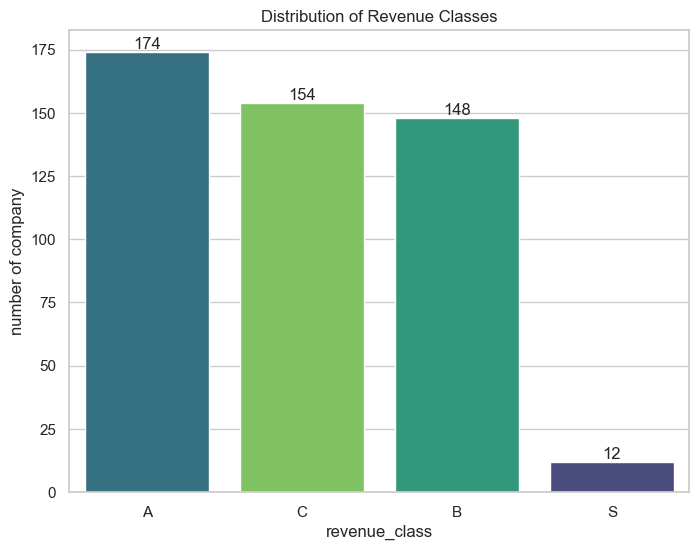

In [44]:
plt.figure(figsize=(8, 6))
ax = sns.countplot(data=df, x='revenue_class',
                    hue='revenue_class',
                    order=df['revenue_class'].value_counts().index, 
                    palette='viridis',
                    legend=False)
plt.title('Distribution of Revenue Classes', fontsize=12)
plt.ylabel('number of company')

for container in ax.containers:
    ax.bar_label(container, fontsize=12) # type: ignore

plt.show()

### テキスト長の分布

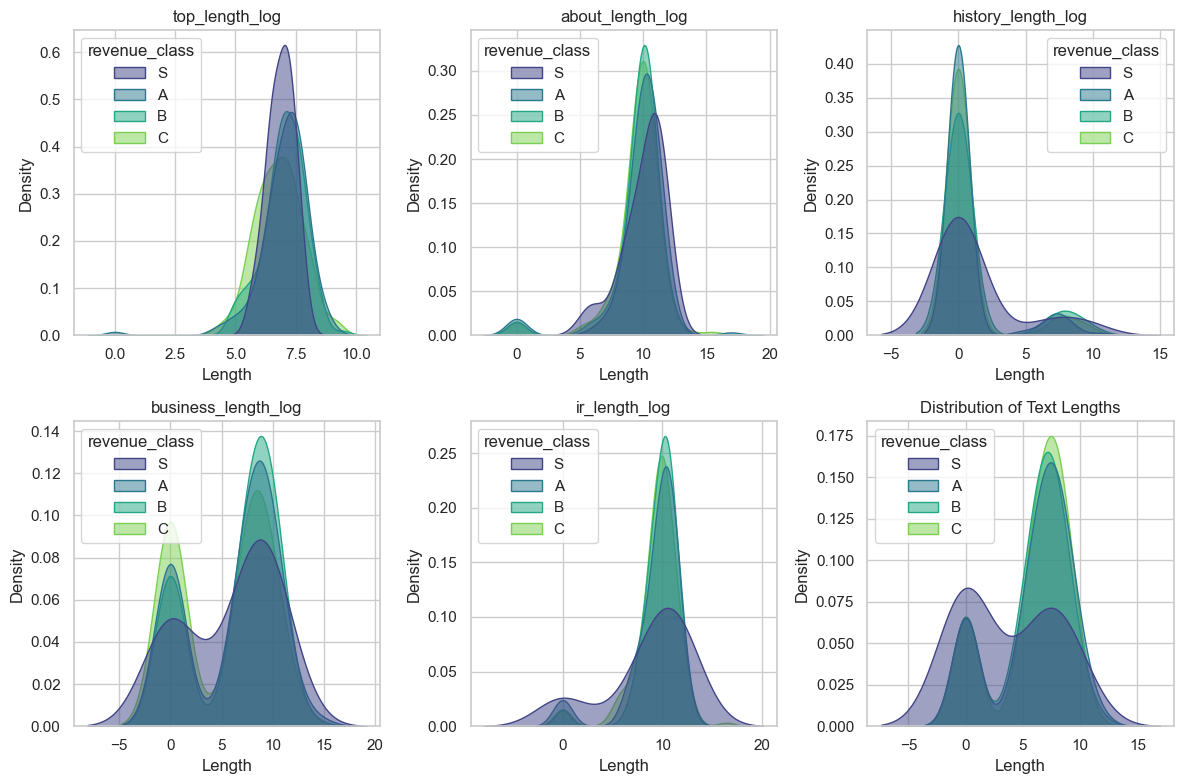

In [32]:
# テキスト長に関するカラムを抽出（'_length' や '_length_log' を含むものを探します）
length_cols = [col for col in df.columns if 'length' in col]

# グラフを描画（最大6個まで並べます）
plt.figure(figsize=(12, 8))
for i, col in enumerate(length_cols[:6], 1):
    plt.subplot(2, 3, i)
    # クラスごとに色分けして分布の山を描画
    sns.kdeplot(data=df, x=col, hue='revenue_class', fill=True, common_norm=False, palette='viridis', alpha=0.5)
    plt.title(f'{col}')
    plt.xlabel('Length')
plt.title('Distribution of Text Lengths', fontsize=12)
plt.tight_layout()
plt.show()

### ベクトルの次元削減（t-SNE）によるクラス分離の確認

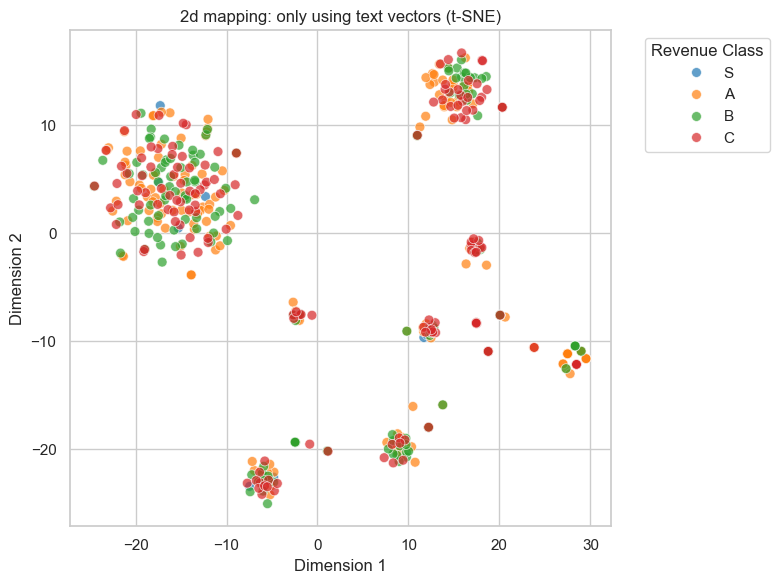

In [45]:
# -------- 1. テキストベクトルのみの次元削減と可視化 ---------


# 1. ベクトル列（'_vec_'を含む列）だけを抽出
vec_cols = [c for c in df.columns if '_vec_' in c]
X_vec = df[vec_cols].fillna(0).values
y_class = df['revenue_class']

# 2. PCAで一旦50次元に落とす（計算の高速化とノイズ除去のため）
pca = PCA(n_components=50, random_state=42)
X_pca = pca.fit_transform(X_vec)

# 3. t-SNEで2次元に圧縮
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
embedding = tsne.fit_transform(X_pca)

# 4. 散布図としてプロット
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=embedding[:, 0], 
    y=embedding[:, 1], 
    hue=y_class, 
    palette='tab10', 
    alpha=0.7, 
    s=50
)
plt.title('2d mapping: only using text vectors (t-SNE)', fontsize=12)
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.legend(title='Revenue Class', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

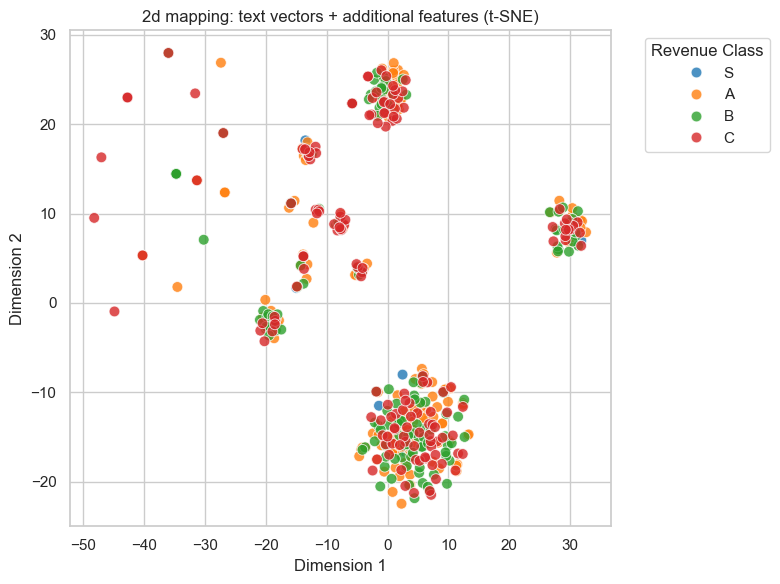

In [46]:
# -------- 2. テキストベクトル+追加特徴量の次元削減と可視化 ---------
from sklearn.preprocessing import StandardScaler

# グラフの見た目設定
sns.set_theme(style="whitegrid")

# データの読み込み（すでに df がある場合は不要ですが、念のため）
df = pd.read_parquet('../data/train_features.parquet')

# 1. 目的変数（ラベル）と不要な列を除外し、特徴量だけを抽出
drop_cols = ['company_name', 'url', 'revenue_class']
# 数値型のカラムだけを全て取得（フラグ、スコア、文字数、ベクトルの全てが含まれます）
feature_cols = [c for c in df.columns if c not in drop_cols and pd.api.types.is_numeric_dtype(df[c])]

X_all = df[feature_cols].fillna(0).values
y_class = df['revenue_class']

# 2. ★超重要★ データのスケール（単位）を統一する（標準化）
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_all)

# 3. PCAで次元を圧縮（ノイズ除去と計算の安定化）
pca = PCA(n_components=50, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# 4. t-SNEで2次元にマッピング
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
embedding = tsne.fit_transform(X_pca)

# 5. 散布図としてプロット
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=embedding[:, 0], 
    y=embedding[:, 1], 
    hue=y_class, 
    palette='tab10', 
    alpha=0.8, 
    s=60,
    edgecolor='w'
)
plt.title('2d mapping: text vectors + additional features (t-SNE)', fontsize=12)
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.legend(title='Revenue Class', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

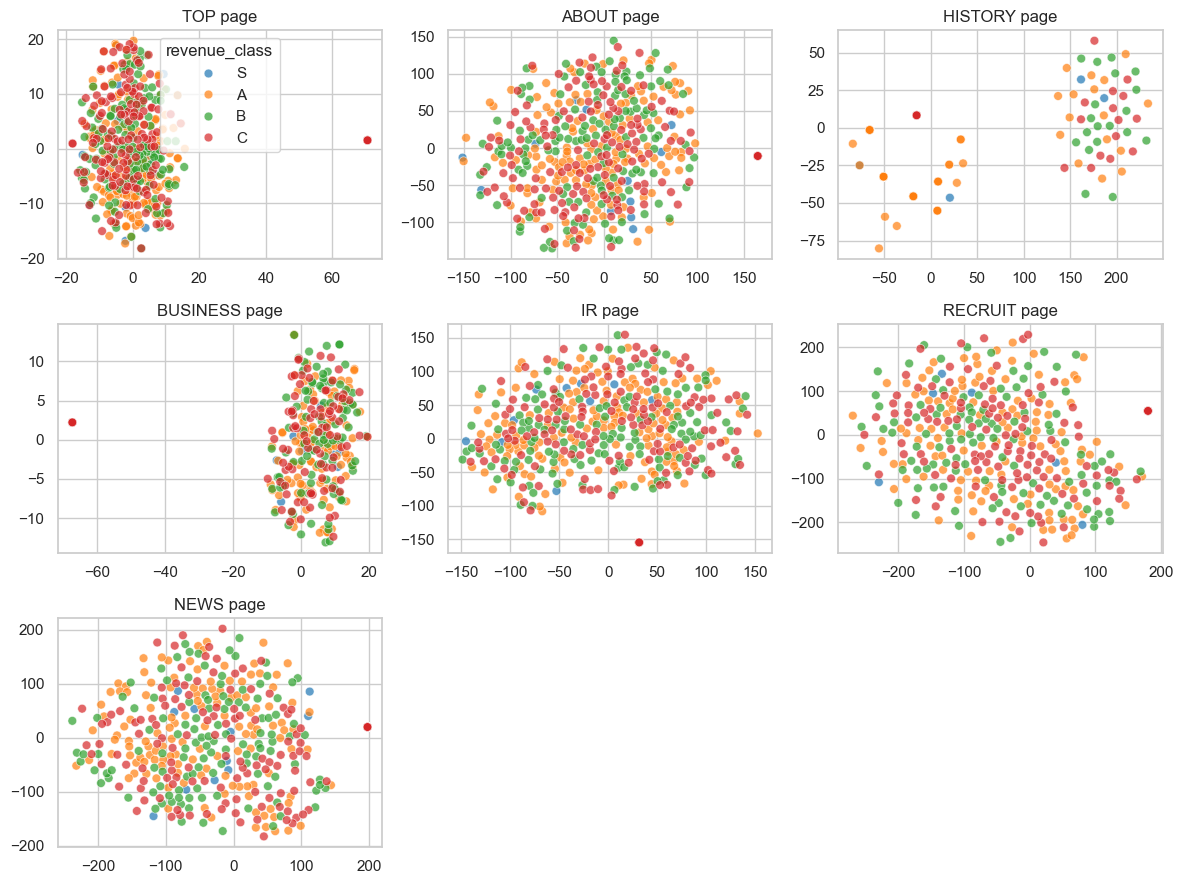

In [56]:

# グラフの見た目設定
sns.set_theme(style="whitegrid")

# 調べるページの種類リスト
page_types = ['top', 'about', 'history', 'business', 'ir', 'recruit', 'news']

# グラフを並べる枠組みを作る (3行3列のパネル)
fig, axes = plt.subplots(3, 3, figsize=(12, 9))
axes = axes.flatten()
y_class = df['revenue_class']


for i, page in enumerate(page_types):
    ax = axes[i]
    # そのページ専用のベクトル列（例: top_vec_0, top_vec_1...）だけを抽出
    vec_cols = [c for c in df.columns if c.startswith(f"{page}_vec_")]
    
    if len(vec_cols) == 0:
        ax.set_title(f"{page.upper()}: データなし")
        ax.axis('off')
        continue
    
    # 欠損値（ページが存在しなかった企業）は0で埋める
    X_vec = df[vec_cols].fillna(0).values
    
    # 次元削減 (PCAで50次元に圧縮 → t-SNEで2次元に圧縮)
    n_comp = min(50, X_vec.shape[1])
    pca = PCA(n_components=n_comp, random_state=42)
    X_pca = pca.fit_transform(X_vec)
    
    tsne = TSNE(n_components=2, perplexity=30, random_state=42)
    embedding = tsne.fit_transform(X_pca)
    
    # 散布図プロット
    sns.scatterplot(
        x=embedding[:, 0], 
        y=embedding[:, 1], 
        hue=y_class, 
        palette='tab10', 
        alpha=0.7, 
        s=40,
        ax=ax,
        legend=(i==0) # 凡例は最初のグラフ(top)だけに出す
    )
    
    ax.set_title(f'{page.upper()} page', fontsize=12)
    ax.set_xlabel('')
    ax.set_ylabel('')
    
    # 最初のグラフの凡例の位置調整
    if i == 8:
        ax.legend(title='Revenue Class', fontsize=12)

# 余った空の枠（8個目、9個目）を非表示にする
for j in range(len(page_types), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

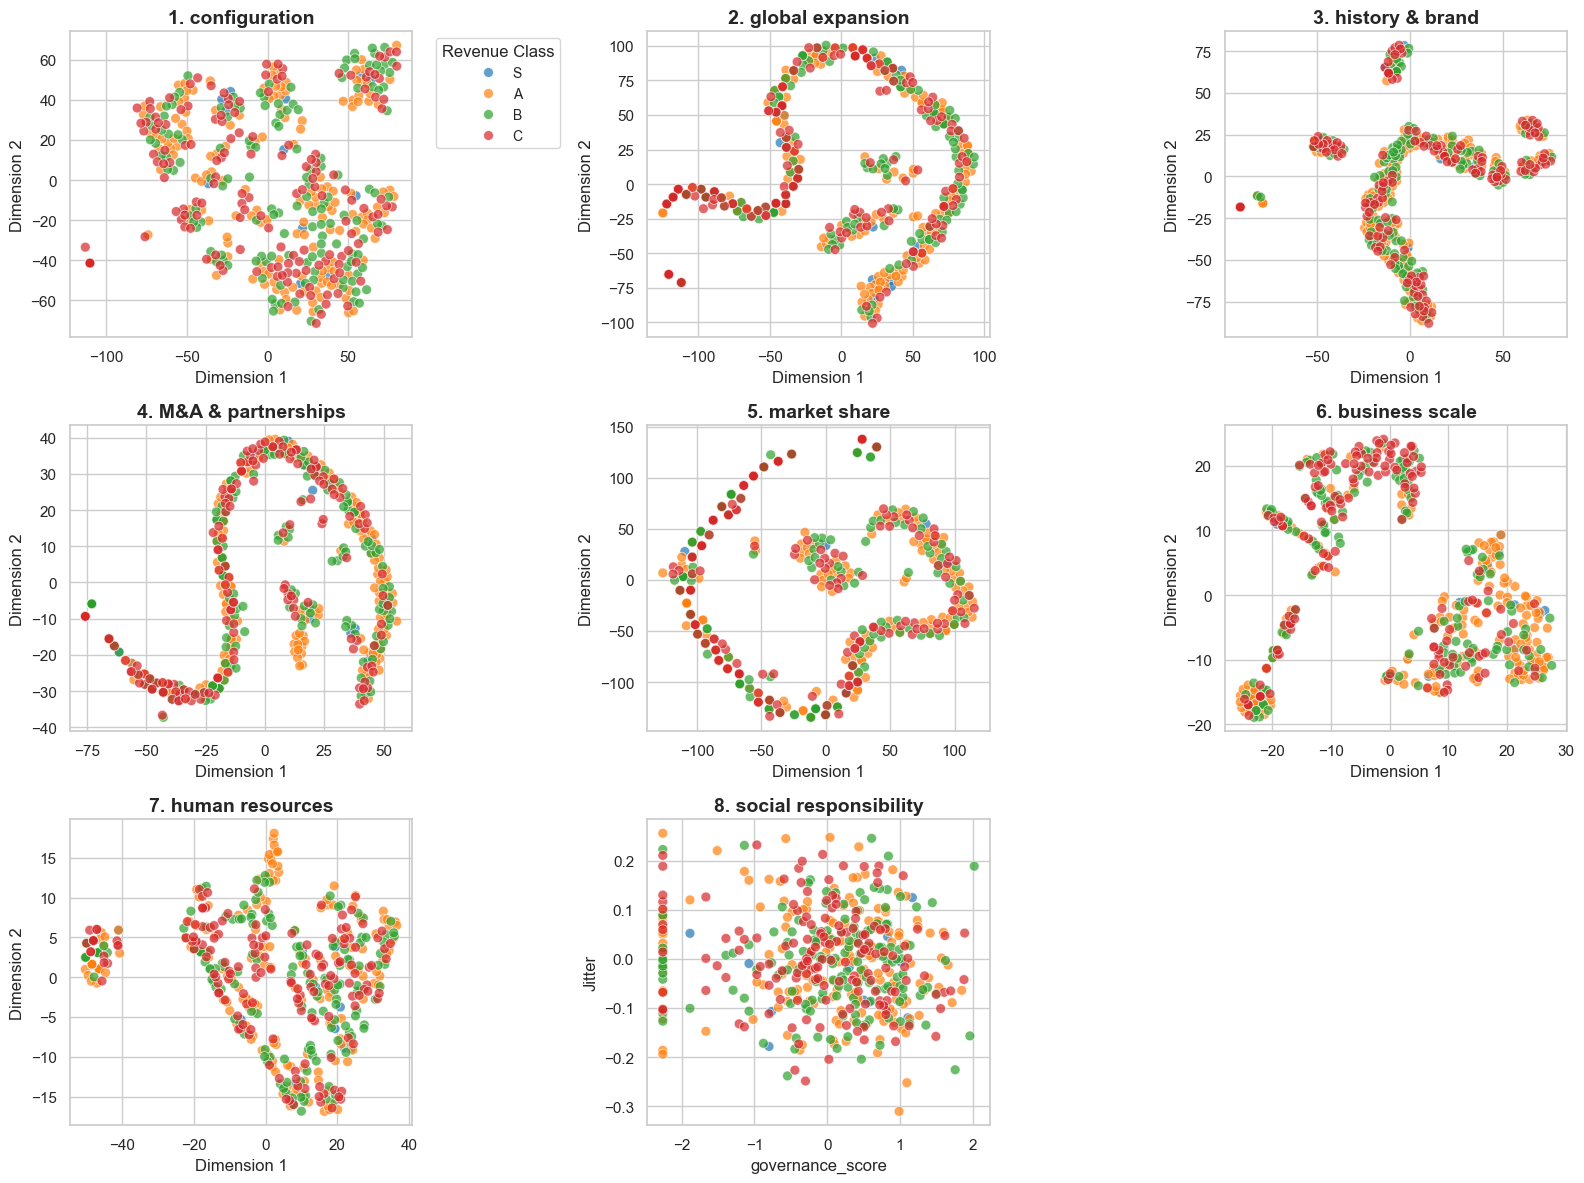

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# グラフの見た目設定
sns.set_theme(style="whitegrid")

# 1. ページごとの構造的特徴の列名リストを作成
pages = ['top', 'about', 'history', 'business', 'ir', 'recruit', 'news']
struct_cols = []
for p in pages:
    struct_cols.extend([f"has_{p}", f"{p}_length_log", f"{p}_ratio"])

# 2. 辞書形式でカテゴリごとに特徴量を定義
feature_groups = {
    '1. configuration': struct_cols,
    '2. global expansion': ['global_word_score', 'overseas_sales_ratio', 'global_bases'],
    '3. history & brand': ['era_word_score', 'founding_year'],
    '4. M&A & partnerships': ['ma_word_score', 'subsidiaries_count', 'partners_count'],
    '5. market share': ['market_leader_score', 'domestic_share_pct'],
    '6. business scale': ['num_business_types', 'money_cho_score', 'money_oku_score'],
    '7. human resources': ['welfare_word_score', 'employees_count', 'num_job_types'],
    '8. social responsibility': ['governance_score']
}

# プロット用の枠を作成 (3行3列)
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
y_class = df['revenue_class']

for i, (group_name, cols) in enumerate(feature_groups.items()):
    ax = axes[i]
    
    # データフレームに存在する列だけを抽出（念のためのエラー回避）
    valid_cols = [c for c in cols if c in df.columns]
    
    if len(valid_cols) == 0:
        ax.set_title(f"{group_name} (データなし)")
        ax.axis('off')
        continue
    
    # 欠損値を0で埋めてデータを取得
    X_raw = df[valid_cols].fillna(0).values
    
    # ★超重要★: 単位が違う数値データを比較可能にするため標準化する
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_raw)
    
    # 次元数によって処理を分ける
    if X_scaled.shape[1] >= 2:
        # 2次元以上の場合は t-SNE で2次元に圧縮
        n_comp = min(50, X_scaled.shape[1])
        if n_comp > 2:
            X_pca = PCA(n_components=n_comp, random_state=42).fit_transform(X_scaled)
        else:
            X_pca = X_scaled
            
        tsne = TSNE(n_components=2, perplexity=30, random_state=42)
        embedding = tsne.fit_transform(X_pca)
        x_plot, y_plot = embedding[:, 0], embedding[:, 1]
    else:
        # 1次元（社会責任など）の場合は、t-SNEができないのでそのままX軸に使い、Y軸はバラけさせる（ジッター）
        x_plot = X_scaled[:, 0]
        y_plot = np.random.normal(0, 0.1, size=len(x_plot))

    # 散布図プロット
    sns.scatterplot(
        x=x_plot, 
        y=y_plot, 
        hue=y_class, 
        palette='tab10', 
        alpha=0.7, 
        s=50,
        ax=ax,
        legend=(i==0) # 凡例は最初のグラフだけに出す
    )
    
    ax.set_title(f'{group_name}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Dimension 1' if X_scaled.shape[1] >= 2 else valid_cols[0])
    ax.set_ylabel('Dimension 2' if X_scaled.shape[1] >= 2 else 'Jitter')
    
    if i == 0:
        ax.legend(title='Revenue Class', fontsize=10, bbox_to_anchor=(1.05, 1), loc='upper left')

# 余った空の枠（9個目）を非表示にする
fig.delaxes(axes[8])

plt.tight_layout()
plt.show()

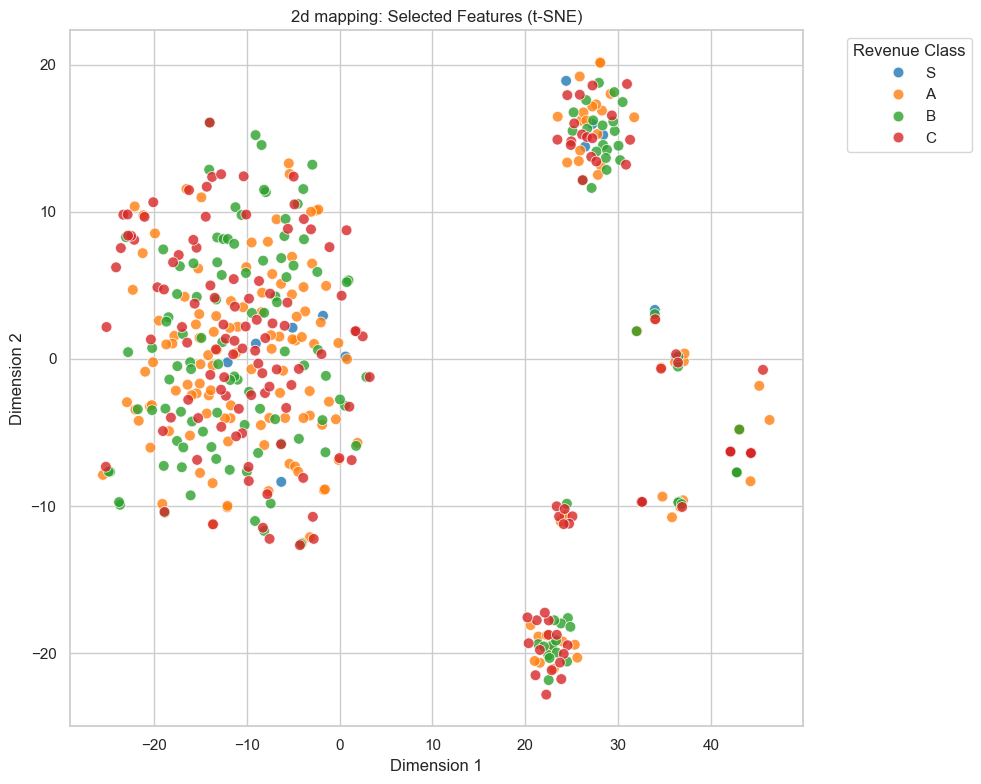

🌟 1. シルエットスコア: -0.0807
   (目安: 0.2以上なら意味のある分離、0.5以上なら非常に綺麗)

🎯 2. k-NN 空間予測の正解率(Accuracy): 0.3320
   (目安: クラス数が例えば5つの場合、適当に当てると0.2(20%)。
    この数字がLightGBMのAccuracyに近いほど、t-SNEの図が本質を捉えている証拠です)


In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
sns.set_theme(style="whitegrid")

df = pd.read_parquet('../data/train_features.parquet')


# 1. 抽出する特徴量のリストアップ
# ① 特定の4ページに関する構造的特徴とベクトル特徴
target_pages = ['about', 'ir', 'recruit', 'news']
page_features = []
for p in target_pages:
    # 構造的特徴（ページの有無、文字数、割合）
    page_features.extend([f"has_{p}", f"{p}_length_log", f"{p}_ratio"])
    # そのページのベクトル特徴（5000次元の一部）
    vec_cols = [c for c in df.columns if c.startswith(f"{p}_vec_")]
    page_features.extend(vec_cols)

# ② 指定された追加カテゴリの特徴量
global_features = ['global_word_score', 'overseas_sales_ratio', 'global_bases']
ma_features = ['ma_word_score', 'subsidiaries_count', 'partners_count']
market_share_features = ['market_leader_score', 'domestic_share_pct']
scale_features = ['num_business_types', 'money_cho_score', 'money_oku_score']

# 全てを結合
selected_features = page_features + global_features + ma_features + market_share_features + scale_features

# データフレームに実際に存在する列だけを抽出（エラー回避）
valid_cols = [c for c in selected_features if c in df.columns]

# 2. データの準備
X = df[valid_cols].fillna(0).values
y_class = df['revenue_class']

# 3. スケーリング（超重要：ベクトルと回数・金額などの単位を揃える）
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. PCAで次元圧縮（ノイズ除去のため一旦50次元へ）
n_comp = min(50, X_scaled.shape[1])
pca = PCA(n_components=n_comp, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# 5. t-SNEで2次元に圧縮
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
embedding = tsne.fit_transform(X_pca)

# 6. プロット
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=embedding[:, 0], 
    y=embedding[:, 1], 
    hue=y_class, 
    palette='tab10', 
    alpha=0.8, 
    s=60,
    edgecolor='w'
)
plt.title('2d mapping: Selected Features (t-SNE)', fontsize=12)
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.legend(title='Revenue Class', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

from sklearn.metrics import silhouette_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold
import numpy as np


# ---------------------------------------------------
# 評価1：シルエットスコア（Silhouette Score）
# ---------------------------------------------------
# 「島がどれくらいギュッと固まり、かつ他の島から離れているか」を測る指標
# 値は -1 〜 1 の間。1に近いほど完璧、0付近はごちゃ混ぜ、マイナスは誤分類。
sil_score = silhouette_score(embedding, y_class)
print(f"🌟 1. シルエットスコア: {sil_score:.4f}")
print("   (目安: 0.2以上なら意味のある分離、0.5以上なら非常に綺麗)")


# ---------------------------------------------------
# 評価2：k-NN（k近傍法）による空間予測テスト
# ---------------------------------------------------
# 「2次元の地図上で、自分のすぐ近くにいる5社のクラスを見て、自分のクラスを当てる」テスト
knn = KNeighborsClassifier(n_neighbors=5)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

knn_scores = []
for train_idx, val_idx in cv.split(embedding, y_class):
    X_train, X_val = embedding[train_idx], embedding[val_idx]
    y_train, y_val = y_class.iloc[train_idx], y_class.iloc[val_idx]
    
    knn.fit(X_train, y_train)
    score = knn.score(X_val, y_val)
    knn_scores.append(score)

mean_knn_score = np.mean(knn_scores)
print(f"\n🎯 2. k-NN 空間予測の正解率(Accuracy): {mean_knn_score:.4f}")
print("   (目安: クラス数が例えば5つの場合、適当に当てると0.2(20%)。")
print("    この数字がLightGBMのAccuracyに近いほど、t-SNEの図が本質を捉えている証拠です)")